In [3]:
import pandas as pd

df = pd.read_csv(
    "../data/raw/student-mat.csv",
    sep=None,
    engine="python"
)

print("Shape:", df.shape)
print("Number of columns:", len(df.columns))
print(df.columns.tolist())

Shape: (395, 33)
Number of columns: 33
['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu', 'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime', 'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2', 'G3']


In [4]:
print("\nDataset Information:")
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())


Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      395 non-null    object
 1   sex         395 non-null    object
 2   age         395 non-null    int64 
 3   address     395 non-null    object
 4   famsize     395 non-null    object
 5   Pstatus     395 non-null    object
 6   Medu        395 non-null    int64 
 7   Fedu        395 non-null    int64 
 8   Mjob        395 non-null    object
 9   Fjob        395 non-null    object
 10  reason      395 non-null    object
 11  guardian    395 non-null    object
 12  traveltime  395 non-null    int64 
 13  studytime   395 non-null    int64 
 14  failures    395 non-null    int64 
 15  schoolsup   395 non-null    object
 16  famsup      395 non-null    object
 17  paid        395 non-null    object
 18  activities  395 non-null    object
 19  nursery     395 non-null    

In [5]:
print("\nDescriptive Statistics:")
print(df[["age", "studytime", "failures", "absences", "G1", "G2", "G3"]].describe())


Descriptive Statistics:
              age   studytime    failures    absences          G1          G2  \
count  395.000000  395.000000  395.000000  395.000000  395.000000  395.000000   
mean    16.696203    2.035443    0.334177    5.708861   10.908861   10.713924   
std      1.276043    0.839240    0.743651    8.003096    3.319195    3.761505   
min     15.000000    1.000000    0.000000    0.000000    3.000000    0.000000   
25%     16.000000    1.000000    0.000000    0.000000    8.000000    9.000000   
50%     17.000000    2.000000    0.000000    4.000000   11.000000   11.000000   
75%     18.000000    2.000000    0.000000    8.000000   13.000000   13.000000   
max     22.000000    4.000000    3.000000   75.000000   19.000000   19.000000   

               G3  
count  395.000000  
mean    10.415190  
std      4.581443  
min      0.000000  
25%      8.000000  
50%     11.000000  
75%     14.000000  
max     20.000000  


In [6]:
print("\nAverage Final Grade by Study Time:")
print(df.groupby("studytime")["G3"].mean())


Average Final Grade by Study Time:
studytime
1    10.047619
2    10.171717
3    11.400000
4    11.259259
Name: G3, dtype: float64


In [7]:
print("\nAverage Final Grade by Absence Level:")

df["absence_level"] = pd.cut(
    df["absences"],
    bins=[-1, 5, 10, 20, 100],
    labels=["Low", "Medium", "High", "Very High"]
)

print(df.groupby("absence_level", observed=True)["G3"].mean())


Average Final Grade by Absence Level:
absence_level
Low          10.168675
Medium       11.400000
High         10.117647
Very High    10.266667
Name: G3, dtype: float64


In [8]:
print("\nAverage Final Grade by Previous Failures:")
print(df.groupby("failures")["G3"].mean())


Average Final Grade by Previous Failures:
failures
0    11.253205
1     8.120000
2     6.235294
3     5.687500
Name: G3, dtype: float64


In [9]:
print("\nAverage Final Grade by School Support:")
print(df.groupby("schoolsup")["G3"].mean())


Average Final Grade by School Support:
schoolsup
no     10.561047
yes     9.431373
Name: G3, dtype: float64


In [10]:
print("\nAverage Final Grade by Family Support:")
print(df.groupby("famsup")["G3"].mean())


Average Final Grade by Family Support:
famsup
no     10.640523
yes    10.272727
Name: G3, dtype: float64


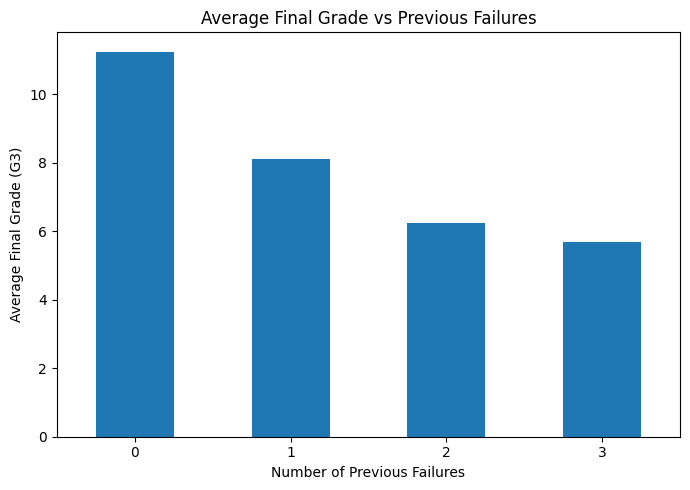

In [11]:
import matplotlib.pyplot as plt

# Average final grade by previous failures
failure_grade = df.groupby("failures")["G3"].mean()

plt.figure(figsize=(7, 5))
failure_grade.plot(kind="bar")

plt.title("Average Final Grade vs Previous Failures")
plt.xlabel("Number of Previous Failures")
plt.ylabel("Average Final Grade (G3)")
plt.xticks(rotation=0)

plt.tight_layout()
plt.savefig("../analysis/failure_vs_grade.png", dpi=300)
plt.show()

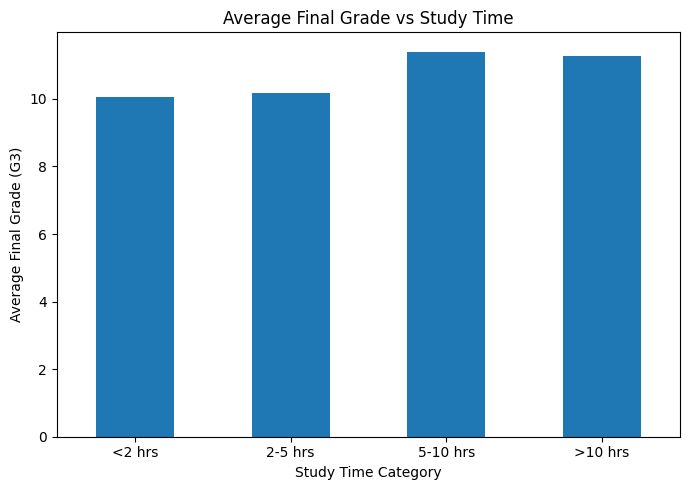

In [12]:
# Average final grade by study time
study_grade = df.groupby("studytime")["G3"].mean()

plt.figure(figsize=(7, 5))
study_grade.plot(kind="bar")

plt.title("Average Final Grade vs Study Time")
plt.xlabel("Study Time Category")
plt.ylabel("Average Final Grade (G3)")
plt.xticks(
    ticks=[0, 1, 2, 3],
    labels=["<2 hrs", "2-5 hrs", "5-10 hrs", ">10 hrs"],
    rotation=0
)

plt.tight_layout()

plt.savefig("../analysis/studytime_vs_grade.png", dpi=300)

plt.show()

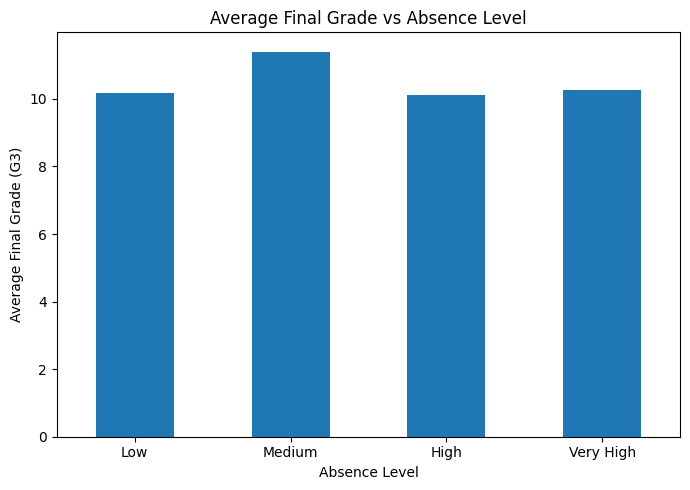

In [13]:
# Average final grade by absence level
absence_grade = df.groupby("absence_level", observed=True)["G3"].mean()

plt.figure(figsize=(7, 5))
absence_grade.plot(kind="bar")

plt.title("Average Final Grade vs Absence Level")
plt.xlabel("Absence Level")
plt.ylabel("Average Final Grade (G3)")
plt.xticks(rotation=0)

plt.tight_layout()

plt.savefig("../analysis/absence_vs_grade.png", dpi=300)

plt.show()


Correlation Matrix:
                age  studytime  failures  absences        G1        G2  \
age        1.000000  -0.004140  0.243665  0.175230 -0.064081 -0.143474   
studytime -0.004140   1.000000 -0.173563 -0.062700  0.160612  0.135880   
failures   0.243665  -0.173563  1.000000  0.063726 -0.354718 -0.355896   
absences   0.175230  -0.062700  0.063726  1.000000 -0.031003 -0.031777   
G1        -0.064081   0.160612 -0.354718 -0.031003  1.000000  0.852118   
G2        -0.143474   0.135880 -0.355896 -0.031777  0.852118  1.000000   
G3        -0.161579   0.097820 -0.360415  0.034247  0.801468  0.904868   

                 G3  
age       -0.161579  
studytime  0.097820  
failures  -0.360415  
absences   0.034247  
G1         0.801468  
G2         0.904868  
G3         1.000000  


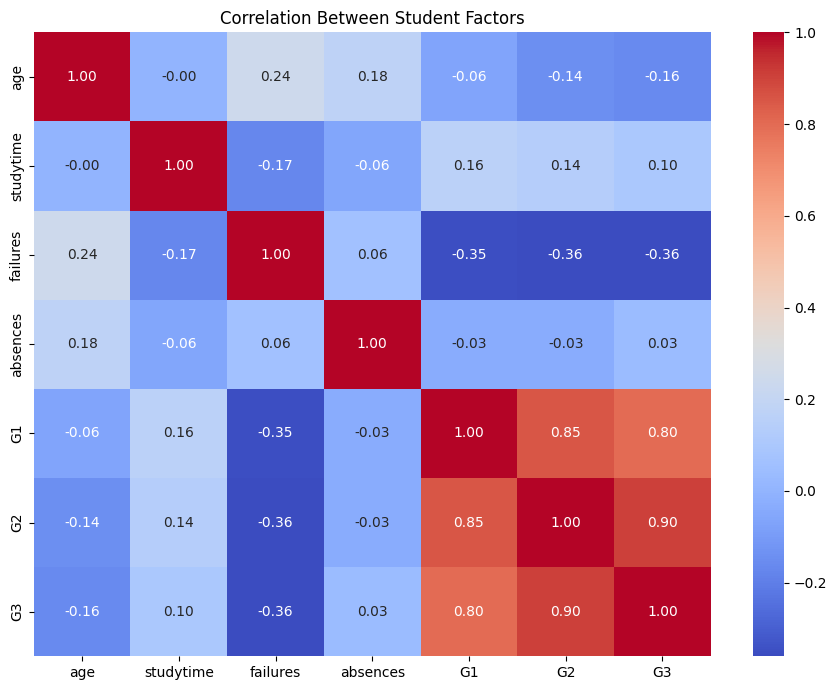

In [14]:
import seaborn as sns

# Select numerical factors
numeric_data = df[
    ["age", "studytime", "failures", "absences", "G1", "G2", "G3"]
]

# Correlation matrix
correlation = numeric_data.corr()

print("\nCorrelation Matrix:")
print(correlation)

# Heatmap
plt.figure(figsize=(9, 7))
sns.heatmap(correlation, annot=True, cmap="coolwarm", fmt=".2f")

plt.title("Correlation Between Student Factors")
plt.tight_layout()

plt.savefig("../analysis/correlation_heatmap.png", dpi=300)

plt.show()

In [15]:
# Create Academic Performance Score
df["academic_score"] = df[["G1", "G2", "G3"]].mean(axis=1)

print("\nAcademic Performance Score:")
print(df["academic_score"].describe())


Academic Performance Score:
count    395.000000
mean      10.679325
std        3.696786
min        1.333333
25%        8.333333
50%       10.666667
75%       13.333333
max       19.333333
Name: academic_score, dtype: float64


In [16]:
# Learning behavior indicators

df["study_time_indicator"] = df["studytime"]

df["absence_score"] = 100 - (
    df["absences"] / df["absences"].max()
) * 100

print("\nLearning Behavior Indicators:")
print(df[[
    "study_time_indicator",
    "absence_score"
]].describe())


Learning Behavior Indicators:
       study_time_indicator  absence_score
count            395.000000     395.000000
mean               2.035443      92.388186
std                0.839240      10.670794
min                1.000000       0.000000
25%                1.000000      89.333333
50%                2.000000      94.666667
75%                2.000000     100.000000
max                4.000000     100.000000


In [17]:
# Academic Risk Indicator

def calculate_risk(failures):
    if failures == 0:
        return "Low"
    elif failures == 1:
        return "Moderate"
    else:
        return "High"

df["academic_risk"] = df["failures"].apply(calculate_risk)

print("\nAcademic Risk Distribution:")
print(df["academic_risk"].value_counts())


Academic Risk Distribution:
academic_risk
Low         312
Moderate     50
High         33
Name: count, dtype: int64


In [18]:
print("\nSchool Support by Academic Risk:")

support_risk = pd.crosstab(
    df["academic_risk"],
    df["schoolsup"]
)

print(support_risk)


School Support by Academic Risk:
schoolsup       no  yes
academic_risk          
High            29    4
Low            272   40
Moderate        43    7


In [19]:
# BeyondMarks Student Profile
profile_data = df[
    [
        "academic_score",
        "study_time_indicator",
        "absence_score",
        "academic_risk",
        "schoolsup",
        "activities",
        "higher"
    ]
]

print("\nBeyondMarks Student Profile:")
print(profile_data.head(10))


BeyondMarks Student Profile:
   academic_score  study_time_indicator  absence_score academic_risk  \
0        5.666667                     2      92.000000           Low   
1        5.333333                     2      94.666667           Low   
2        8.333333                     2      86.666667          High   
3       14.666667                     3      97.333333           Low   
4        8.666667                     2      94.666667           Low   
5       15.000000                     2      86.666667           Low   
6       11.666667                     2     100.000000           Low   
7        5.666667                     2      92.000000           Low   
8       17.666667                     2     100.000000           Low   
9       14.666667                     2     100.000000           Low   

  schoolsup activities higher  
0       yes         no    yes  
1        no         no    yes  
2       yes         no    yes  
3        no        yes    yes  
4        no      

In [20]:
# -----------------------------
# O*NET DATA INSPECTION
# -----------------------------

occupation_df = pd.read_csv(
    "../data/raw/occupation_data.csv"
)

skills_df = pd.read_csv(
    "../data/raw/transferable_skills.csv"
)

print("\nO*NET Occupation Data:")
print(occupation_df.head())
print("Shape:", occupation_df.shape)
print("Columns:", occupation_df.columns.tolist())

print("\nO*NET Transferable Skills:")
print(skills_df.head())
print("Shape:", skills_df.shape)
print("Columns:", skills_df.columns.tolist())


O*NET Occupation Data:
  O*NET-SOC Code                                Title  \
0     11-1011.00                     Chief Executives   
1     11-1011.03        Chief Sustainability Officers   
2     11-1021.00      General and Operations Managers   
3     11-1031.00                          Legislators   
4     11-2011.00  Advertising and Promotions Managers   

                                         Description  
0  Determine and formulate policies and provide o...  
1  Communicate and coordinate with management, sh...  
2  Plan, direct, or coordinate the operations of ...  
3  Develop, introduce, or enact laws and statutes...  
4  Plan, direct, or coordinate advertising polici...  
Shape: (1016, 3)
Columns: ['O*NET-SOC Code', 'Title', 'Description']

O*NET Transferable Skills:
  O*NET-SOC Code             Title Element ID           Element Name Scale ID  \
0     11-1011.00  Chief Executives    2.B.1.a  Social Perceptiveness       IM   
1     11-1011.00  Chief Executives    2.B.1.

In [21]:
# Find analyst-related occupations

keywords = (
    "Analyst|"
    "Business Intelligence|"
    "Data Scientist|"
    "Operations Research|"
    "Statistician"
)

analyst_jobs = occupation_df[
    occupation_df["Title"].str.contains(
        keywords,
        case=False,
        na=False
    )
]

print("\nAnalyst-related O*NET Occupations:")
print(
    analyst_jobs[
        ["O*NET-SOC Code", "Title"]
    ].to_string(index=False)
)


Analyst-related O*NET Occupations:
O*NET-SOC Code                                              Title
    13-1081.02                                 Logistics Analysts
    13-1111.00                                Management Analysts
    13-1161.00 Market Research Analysts and Marketing Specialists
    13-2031.00                                    Budget Analysts
    13-2041.00                                    Credit Analysts
    13-2051.00                  Financial and Investment Analysts
    13-2099.01                    Financial Quantitative Analysts
    13-2099.04        Fraud Examiners, Investigators and Analysts
    15-1211.00                          Computer Systems Analysts
    15-1212.00                      Information Security Analysts
    15-1253.00    Software Quality Assurance Analysts and Testers
    15-1299.06                         Digital Forensics Analysts
    15-2031.00                       Operations Research Analysts
    15-2041.00                          

In [22]:
# Load O*NET Software Skills
software_df = pd.read_csv(
    "../data/raw/software_skills.csv"
)

print("\nO*NET Software Skills:")
print(software_df.head())

print("Shape:", software_df.shape)

print("Columns:")
print(software_df.columns.tolist())


O*NET Software Skills:
  O*NET-SOC Code             Title  \
0     11-1011.00  Chief Executives   
1     11-1011.00  Chief Executives   
2     11-1011.00  Chief Executives   
3     11-1011.00  Chief Executives   
4     11-1011.00  Chief Executives   

                               Workplace Example Element ID  \
0                                  Adobe Acrobat    2.E.5.b   
1                                AdSense Tracker    2.E.6.f   
2                                 Atlassian JIRA    2.E.5.a   
3                    Blackbaud The Raiser's Edge    2.E.6.c   
4  ComputerEase construction accounting software    2.E.2.a   

                                    Element Name Hot Technology In Demand  
0                   Document management software              Y         N  
1    Data base user interface and query software              N         N  
2                      Content workflow software              Y         N  
3  Customer relationship management CRM software              N 

In [23]:
# Business Intelligence Analyst technologies

bi_code = "15-2051.01"

bi_software = software_df[
    software_df["O*NET-SOC Code"] == bi_code
]

tech_names = [
    "Microsoft Excel",
    "Microsoft Power BI",
    "Tableau",
    "SQL",
    "Python",
    "R",
    "SAS",
    "Alteryx"
]

data_analytics_tech = bi_software[
    bi_software["Workplace Example"].isin(tech_names)
]

print("\nData Analytics Technologies:")

print(
    f"{'Workplace Example':<25}"
    f"{'Element Name':<50}"
    f"{'Hot Technology':<15}"
    f"{'In Demand':<10}"
)

print("-" * 100)

for _, row in data_analytics_tech.iterrows():
    print(
        f"{row['Workplace Example']:<25}"
        f"{row['Element Name']:<50}"
        f"{row['Hot Technology']:<15}"
        f"{row['In Demand']:<10}"
    )


Data Analytics Technologies:
Workplace Example        Element Name                                      Hot Technology In Demand 
----------------------------------------------------------------------------------------------------
Microsoft Excel          Spreadsheet software                              Y              Y         
Microsoft Power BI       Business intelligence and data analysis software  Y              Y         
Python                   Object or component oriented development software Y              Y         
R                        Object or component oriented development software Y              Y         
SAS                      Analytical or scientific software                 Y              Y         
Tableau                  Business intelligence and data analysis software  Y              Y         


In [24]:
# Create final technology list for Business Intelligence Analyst

skill_keywords = [
    "Excel",
    "Power BI",
    "Tableau",
    "SQL",
    "Python",
    "SAS",
    "Alteryx"
]

skill_list = []

for keyword in skill_keywords:
    matches = bi_software[
        bi_software["Workplace Example"]
        .str.contains(keyword, case=False, na=False)
    ]

    if not matches.empty:
        skill_list.append(keyword)

print("\nFinal Career Skill List:")
for skill in skill_list:
    print("-", skill)


Final Career Skill List:
- Excel
- Power BI
- Tableau
- SQL
- Python
- SAS
- Alteryx


###  STUDENT LEARNING PROFILE

In [26]:
# Academic score
df["academic_score"] = (
    df["G1"] + df["G2"] + df["G3"]
) / 3

# Learning profile
df["learning_profile"] = "Balanced"

# Conditions
strong_academic = (
    df["academic_score"] >= df["academic_score"].median()
)

good_study = (
    df["studytime"] >= 3
)

low_failures = (
    df["failures"] == 0
)

active = (
    df["activities"] == "yes"
)

# Strong learner
df.loc[
    strong_academic &
    good_study &
    low_failures,
    "learning_profile"
] = "Strong Learner"

# Developing potential
df.loc[
    (~strong_academic) &
    good_study &
    active,
    "learning_profile"
] = "Developing Potential"


# Display results
print("\n===== STUDENT LEARNING PROFILE =====")

print(
    df["learning_profile"].value_counts()
)


===== STUDENT LEARNING PROFILE =====
learning_profile
Balanced                321
Strong Learner           53
Developing Potential     21
Name: count, dtype: int64


In [27]:
print("\n===== SAMPLE STUDENT PROFILES =====")

print(
    df[
        [
            "age",
            "studytime",
            "failures",
            "absences",
            "G1",
            "G2",
            "G3",
            "academic_score",
            "activities",
            "learning_profile"
        ]
    ].head(15).to_string(index=False)
)


===== SAMPLE STUDENT PROFILES =====
 age  studytime  failures  absences  G1  G2  G3  academic_score activities learning_profile
  18          2         0         6   5   6   6        5.666667         no         Balanced
  17          2         0         4   5   5   6        5.333333         no         Balanced
  15          2         3        10   7   8  10        8.333333         no         Balanced
  15          3         0         2  15  14  15       14.666667        yes   Strong Learner
  16          2         0         4   6  10  10        8.666667         no         Balanced
  16          2         0        10  15  15  15       15.000000        yes         Balanced
  16          2         0         0  12  12  11       11.666667         no         Balanced
  17          2         0         6   6   5   6        5.666667         no         Balanced
  15          2         0         0  16  18  19       17.666667         no         Balanced
  15          2         0         0  14  15

### STEP 12 - LEARNING PROFILE SCORE

In [28]:
profile_scores = {
    "Strong Learner": 10,
    "Developing Potential": 5,
    "Balanced": 0
}

df["profile_score"] = df["learning_profile"].map(
    profile_scores
)

print("\n===== LEARNING PROFILE SCORE =====")

print(
    df[
        [
            "learning_profile",
            "profile_score"
        ]
    ].head(15).to_string(index=False)
)


===== LEARNING PROFILE SCORE =====
learning_profile  profile_score
        Balanced              0
        Balanced              0
        Balanced              0
  Strong Learner             10
        Balanced              0
        Balanced              0
        Balanced              0
        Balanced              0
        Balanced              0
        Balanced              0
        Balanced              0
  Strong Learner             10
        Balanced              0
        Balanced              0
  Strong Learner             10
